# General pipeline

#### General pre-processing, cleaning and model training steps relevant for all data versions.
#### It's aim is to experiment with different combinations of features to determine predictive value of features added for enrichment.
#### The pipeline is based on TM-RugPull initial analysis and includes only steps that are relevant and were proven to be useful for the dataset.

In [1]:
 # Loading data from .xlsx file
 # 'data/TM-RugPull_prepared_for_enrichment.xlsx' - baseline (original dataset after cleaning and pre-processing)

import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot

def load_data(filename):
    data = pd.read_excel(filename)
    # Remove a space in the end of some column names
    data.columns = data.columns.str.strip()
    return data

data = load_data('data/TM-RugPull_enriched_v.1.0.xlsx')

data.head(5)

,Project Title,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,...,Holders_1h,Holders_4h,Holders_12h,Holders_24h,has_concentrated_initial_mint,has_contract_swap_patterns,has_owner_guard,has_lp_lock_reference,is_contract_verified,Top200 name similarity
0,HyperVerse Token,7.650000e+00,1.500000e-01,9.100000e-06,8.000000e-07,BSC,623909,25752,0.009537,4.929203e-02,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1,0.5033
1,Fintoch,1.795000e-11,1.907000e-11,1.727000e-10,1.769000e-10,BSC,"1,492,842","147,791",2487.228167,4.503032e+07,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1,0.6333
2,Flare Token,1.955000e-03,5.519000e-04,4.158000e-04,2.838000e-04,BSC,"184,694",15173,890171363872314.625,6.695544e+17,...,7.0,129.0,3106.0,4301.0,0.0,1.0,1.0,0.0,1,0.4000
3,Safuu Protocol,2.070000e+02,2.110000e+02,7.000000e+01,2.400000e+01,BSC,"275,530",151979,24573310762.585602,8.139816e+14,...,2.0,2.0,2.0,2.0,0.0,1.0,1.0,0.0,1,0.3300
4,SCT,2.986000e-01,1.659000e-01,1.831000e-01,1.552000e-01,BSC,8445,"6,126\n",4252172.090125,1.410127e+05,...,1.0,4386.0,4390.0,4392.0,0.0,0.0,1.0,0.0,1,0.6625


In [2]:
# Create a train and test sets from the raw data to avoid data leakage
# A split is temporal, preserving project period balance (based on start date), so that both old and new projects are presented in each split
# Train set size is about 67% and test set size is about 33% from the whole data set

# Reference: https://stackoverflow.com/questions/45516424/sklearn-train-test-split-on-pandas-stratify-by-multiple-columns

from sklearn.model_selection import train_test_split

# Define seed for the whole pipeline
seed = 7

# Group years into broader periods
def assign_project_period(year):
    if year < 2021:
        return 'before_2021'
    elif year in [2021, 2022, 2023]:
        return str(year)
    elif year in [2024, 2025]:
        return '2024_2025'
    else:
        return 'unknown'


# Create train and test sets using temporal stratified split
def create_temporal_stratified_train_test_split():
    # Convert project starting date to datetime and extract year
    data['project starting date'] = pd.to_datetime(data['project starting date'], errors='coerce')
    data['project starting year'] = data['project starting date'].dt.year
    data['project period'] = data['project starting year'].apply(assign_project_period)
    # Combined stratification label for the full dataset (class and project period)
    combined_labels = data['class'].astype(str) + '|' + data['project period'].astype(str)
    # Split the data on train and test sets
    train_set, test_set = train_test_split(data, test_size=0.33, random_state=seed, stratify=combined_labels)

    return train_set, test_set

train_set, test_set = create_temporal_stratified_train_test_split()

# Output the shapes to verify the splits
print("Training set shape:", train_set.shape)
print("Test set shape:", test_set.shape)

# Create a list of sets to perform further feature engineering on all subsets of data
data_sets = [train_set, test_set]

Training set shape: (650, 40)
Test set shape: (321, 40)


In [3]:
# Verify that there is no overlap between sets, no data leak at this stage
print("Overlap between train and test:", np.intersect1d(train_set.index, test_set.index).size)

Overlap between train and test: 0


In [4]:
# Combined stratification labels (class and project period) for cross-validation to make it also temporal

combined_labels_train = train_set['class'].astype(str) + '|' + train_set['project period'].astype(str)
combined_labels_test = test_set['class'].astype(str) + '|' + test_set['project period'].astype(str)

In [5]:
# Delete columns that are not useful for further analysis

def drop_columns(data_sets):
    for data_set in data_sets:
        data_set.drop(columns=['Project Title', 'Sign', 'website', 'x profile', 'Smart Contract (online)', 'smart Contract (offline)', 'project starting date', 'project end date', 'project starting year', 'project period', 'Contract address'], inplace=True)

drop_columns(data_sets)

# Check the result on train set
train_set.head(5)

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,...,Holders_1h,Holders_4h,Holders_12h,Holders_24h,has_concentrated_initial_mint,has_contract_swap_patterns,has_owner_guard,has_lp_lock_reference,is_contract_verified,Top200 name similarity
62,4.184000e-02,4.293000e-02,2.914000e-02,0.023870,BSC,19882,14963,16895075382083.320312,3.594163e+09,520000000,...,3.0,5.0,83.0,118.0,0.0,0.0,1.0,0.0,1,0.3333
52,1.575490e-01,2.778830e-01,2.296480e-01,0.190216,BSC,1119,346,8067680635445.952148,1.882412e+14,100000000,...,6.0,6.0,7.0,86.0,0.0,1.0,1.0,0.0,1,0.6625
671,4.990000e+02,1.709000e+01,2.963000e+01,26.830000,ETH,6892613,7143,25991.062529,7.051642e+06,52631.030113,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1,0.3555
386,7.883000e-07,6.352000e-07,5.435000e-07,101.000000,POLYGON,27,4,12315.725403,1.472422e+04,300,...,3.0,4.0,5.0,7.0,1.0,0.0,1.0,0.0,1,0.3767
402,3.490000e-02,4.043000e-02,7.090000e-02,0.065390,BSC,11131,773,1731826964005.893066,7.485784e+13,100000000,...,4.0,4.0,4.0,4.0,0.0,0.0,1.0,0.0,1,0.4650


In [6]:
# Encode class label

from sklearn.preprocessing import LabelEncoder

def encode_labels(data_sets):
    for data_set in data_sets:
        le = LabelEncoder()
        data_set['class'] = data_set['class'].map({'normal': 0, 'scam': 1})

encode_labels(data_sets)

train_set.head(5)

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,...,Holders_1h,Holders_4h,Holders_12h,Holders_24h,has_concentrated_initial_mint,has_contract_swap_patterns,has_owner_guard,has_lp_lock_reference,is_contract_verified,Top200 name similarity
62,4.184000e-02,4.293000e-02,2.914000e-02,0.023870,BSC,19882,14963,16895075382083.320312,3.594163e+09,520000000,...,3.0,5.0,83.0,118.0,0.0,0.0,1.0,0.0,1,0.3333
52,1.575490e-01,2.778830e-01,2.296480e-01,0.190216,BSC,1119,346,8067680635445.952148,1.882412e+14,100000000,...,6.0,6.0,7.0,86.0,0.0,1.0,1.0,0.0,1,0.6625
671,4.990000e+02,1.709000e+01,2.963000e+01,26.830000,ETH,6892613,7143,25991.062529,7.051642e+06,52631.030113,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1,0.3555
386,7.883000e-07,6.352000e-07,5.435000e-07,101.000000,POLYGON,27,4,12315.725403,1.472422e+04,300,...,3.0,4.0,5.0,7.0,1.0,0.0,1.0,0.0,1,0.3767
402,3.490000e-02,4.043000e-02,7.090000e-02,0.065390,BSC,11131,773,1731826964005.893066,7.485784e+13,100000000,...,4.0,4.0,4.0,4.0,0.0,0.0,1.0,0.0,1,0.4650


In [7]:
# Transform all data to numeric values

# Columns with object datatype
cols_to_clean = [
    'the number of Transactions',
    'Token concentration ratio per holder',
    'Token balance',
    'Total Variance',
    'Google results for project website (first day)',
    'Google results for project website (duration/2)'
]


def transform_values_to_numeric(data_sets, cols_to_clean):
    for i, data_set in enumerate(data_sets):
        for col in cols_to_clean:
            data_sets[i][col] = pd.to_numeric(
                data_set[col].astype(str)
                    .str.replace('\xa0', '', regex=False)        # Remove non-breaking whitespaces
                    .str.replace(',', '', regex=False)           # Strip comas separating numeric values
                    .str.strip(),                                # Remove surrounding whitespaces
                errors='coerce'                                     # If cannot parse, put NaN
            )

transform_values_to_numeric(data_sets, cols_to_clean)

# Verify the result
print("Datatypes:\n", train_set[cols_to_clean].dtypes)
print("\nMissing values:\n", train_set[cols_to_clean].isnull().sum())
print("\nColumns description\n", train_set[cols_to_clean].describe())

Datatypes:
 the number of Transactions                         float64
Token concentration ratio per holder                 int64
Token balance                                      float64
Total Variance                                     float64
Google results for project website (first day)     float64
Google results for project website (duration/2)    float64
dtype: object

Missing values:
 the number of Transactions                         0
Token concentration ratio per holder               0
Token balance                                      1
Total Variance                                     3
Google results for project website (first day)     2
Google results for project website (duration/2)    2
dtype: int64

Columns description
        the number of Transactions  Token concentration ratio per holder  \
count                6.500000e+02                          6.500000e+02   
mean                 9.504783e+05                          7.062752e+06   
std                  1.0

In [8]:
# Capping extreme values at the 99.5 percentile estimated from the training data and applied to all datasets, to avoid errors and warnings

# Reference: S. Galli, Python Feature Engineering Cookbook: Over 70 recipes for creating, engineering, and transforming features to build machine learning models, Packt Publishing, 2022.

cols_to_clip = [
    'Total Variance',
    'Variance of holders with more than 1% tokens'
]

# Clip at 99.5% quantile (computed on train_set only)
upper_q = 0.995

for col in cols_to_clip:
    upper = train_set[col].quantile(upper_q)
    for data_set in data_sets:
        data_set[col] = data_set[col].clip(upper=upper)

In [9]:
# Handle missing values (for numeric 'median' is used due to heavy skew, for categorical values 'most frequent' is used)

# Based on: Géron, A. "End-to-end Machine Learning Project" in 'Hands-on' machine learning with Scikit-Learn, Keras & Tensorflow. (O'Reilly Media, Inc, 2019) 2nd edition.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

from sklearn.impute import SimpleImputer

# Define numeric and categorical columns
numeric_cols = train_set.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train_set.select_dtypes(exclude=['number']).columns.tolist()

# Create inputers and fit to train set
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer.fit(train_set[numeric_cols])
cat_imputer.fit(train_set[categorical_cols])

# Apply to train and test sets
for data_set in data_sets:
    data_set[numeric_cols] = num_imputer.transform(data_set[numeric_cols])
    data_set[categorical_cols] = cat_imputer.transform(data_set[categorical_cols])

# Verify it works (no missing values left)
print("\nRemaining missing values per column in train_set:")
print(train_set.isnull().sum())


Remaining missing values per column in train_set:
MaxPrice (Quarter 1)                                     0
MaxPrice (Quarter 2)                                     0
MaxPrice (Quarter 3)                                     0
MaxPrice (Quarter 4)                                     0
Blockchain                                               0
the number of Transactions                               0
Token concentration ratio per holder                     0
Total Variance                                           0
Variance of holders with more than 1% tokens             0
Token balance                                            0
Blockchain Type                                          0
class                                                    0
Google results for project title (first day)             0
Google results for project title (project duration/2)    0
Google results for project website (first day)           0
Google results for project website (duration/2)          0
Googl

In [10]:
# Encode categorical features ('Blockchain', 'Blockchain Type') to make all features numeric.
# OneHotEncoder was chosen, since the number of categories is small (4 for 'Blockchain' and 3 for 'Blockchain Type'),
# and OneHotEncoder prevents algorithms to treat close values more similar than distant ones.

# Based on: Based on: Géron, A. "End-to-end Machine Learning Project" in 'Hands-on' machine learning with Scikit-Learn, Keras & Tensorflow. (O'Reilly Media, Inc, 2019) 2nd edition.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Blockchain', 'Blockchain Type']
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoder.fit(train_set[categorical_cols])

# Apply to each split
for data_set in data_sets:
    cat_array = cat_encoder.transform(data_set[categorical_cols])
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
    cat_df = pd.DataFrame(cat_array, columns=cat_feature_names, index=data_set.index)

    # Drop original categorical columns
    data_set.drop(columns=categorical_cols, inplace=True)

    # Add encoded columns
    for col in cat_df.columns:
        data_set[col] = cat_df[col]

# Verify it works (all columns are numeric)
print(train_set.dtypes)

MaxPrice (Quarter 1)                                     float64
MaxPrice (Quarter 2)                                     float64
MaxPrice (Quarter 3)                                     float64
MaxPrice (Quarter 4)                                     float64
the number of Transactions                               float64
Token concentration ratio per holder                     float64
Total Variance                                           float64
Variance of holders with more than 1% tokens             float64
Token balance                                            float64
class                                                    float64
Google results for project title (first day)             float64
Google results for project title (project duration/2)    float64
Google results for project website (first day)           float64
Google results for project website (duration/2)          float64
Google results for project x profile (first days)        float64
Google results for projec

In [11]:
# Extract feature names (except 'class') for further interpretability

feature_names = train_set.columns.drop("class").tolist()

print(feature_names)

['MaxPrice (Quarter 1)', 'MaxPrice (Quarter 2)', 'MaxPrice (Quarter 3)', 'MaxPrice (Quarter 4)', 'the number of Transactions', 'Token concentration ratio per holder', 'Total Variance', 'Variance of holders with more than 1% tokens', 'Token balance', 'Google results for project title (first day)', 'Google results for project title (project duration/2)', 'Google results for project website (first day)', 'Google results for project website (duration/2)', 'Google results for project x profile (first days)', 'Google results for project x profile (duration/2)', 'project period (days)', 'Holders_1h', 'Holders_4h', 'Holders_12h', 'Holders_24h', 'has_concentrated_initial_mint', 'has_contract_swap_patterns', 'has_owner_guard', 'has_lp_lock_reference', 'is_contract_verified', 'Top200 name similarity', 'Blockchain_ARBI', 'Blockchain_BSC', 'Blockchain_ETH', 'Blockchain_POLYGON', 'Blockchain Type_Fraud Proofs', 'Blockchain Type_POS', 'Blockchain Type_POSA']


In [12]:
# Transform data to deal with skew
# For columns with heavy skew PowerTransformer is applied

# Reference: M. Kuhn and K. Johnson, Applied Predictive Modeling. New York, NY, USA: Springer, 2013.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html

from sklearn.preprocessing import PowerTransformer

skewed_cols = [
    'MaxPrice (Quarter 1)',
    'MaxPrice (Quarter 2)',
    'MaxPrice (Quarter 3)',
    'MaxPrice (Quarter 4)',
    'Total Variance',
    'Variance of holders with more than 1% tokens',
    'Token balance',
    'Token concentration ratio per holder',
    'the number of Transactions',
    'Google results for project title (first day)',
    'Google results for project title (project duration/2)',
    'Google results for project website (first day)',
    'Google results for project website (duration/2)',
    'Google results for project x profile (first days)',
    'Google results for project x profile (duration/2)'
]

# Yeo-Johnson has been chosen, since it handles zeros safely. At this stage, no scaling is applied
pt = PowerTransformer(method='yeo-johnson', standardize=False)
pt.fit(train_set[skewed_cols].astype(float).values)

for data_set in data_sets:
    data_set[skewed_cols] = pt.transform(data_set[skewed_cols].astype(float).values)

In [13]:
# Separate features from the target variable
# Extract X and Y from train and test sets

# # Reference: CSM010-2024-APR, Topic 5. 5.12 Hands-on programming demo: evaluating models

X_train = train_set.drop(columns=['class']).values
Y_train = train_set['class'].values

X_test = test_set.drop(columns=['class']).values
Y_test = test_set['class'].values

In [14]:
# Helper functions for training and evaluating models

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold

# Reference: K. Erofeeva, the coursework for CSM010-2024-APR module


# Create temporally-aware fold indices, stratified on both class and project period (combined label) to preserve
# the same temporal logic as train / test split.
# 5 folds are used, since the size of the dataset is quite small
# Reference: https://medium.com/@hlfzeus/stratified-splitting-with-stratifiedkfold-using-target-and-group-variables-part-2-eae4d9c7abf7
def make_temporal_kfold_splits(X, combined_labels, n_splits=5, seed=seed):
    stratified_folds = StratifiedKFold(n_splits=n_splits, random_state=seed, shuffle=True)
    return list(stratified_folds.split(X, combined_labels))

# Make pre-computed splits on train and test sets for further cross-validation
splits_train = make_temporal_kfold_splits(X_train, combined_labels_train)
splits_test = make_temporal_kfold_splits(X_test, combined_labels_test)

# Instantiate models
# For models that require scaling StandardScaler and RobustScaler are applied
# For baseline no specific model tuning is implemented. It will be added after enriching the dataset
def instantiate_models():
    models = []
    models.append(('RandomForest', RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)))
    models.append(('XGBoost', XGBClassifier(random_state=seed, eval_metric='logloss', n_jobs=-1)))
    models.append(('KNeighbors', Pipeline([
        ('scaler', RobustScaler()),
        ('model', KNeighborsClassifier())
    ])))
    models.append(('SVC', Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=seed, probability=True))
    ])))
    return models


# Fit a model, make predictions and print classification report and confusion matrix
# Evaluated on test set
def train_model_print_reports_and_matrix(name, model, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    predicted = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name} performance on test set:")
    print(classification_report(Y_test, predicted, digits=3))
    print(confusion_matrix(Y_test, predicted))
    print(f"Test ROC AUC: {roc_auc_score(Y_test, proba):.3f}")


# Assess a model with cross-validation
# A secondary measure of assessment, to evaluate model's stability across different folds (subsets).
def assess_with_cross_val(name, model, splits, X, Y):
    result = cross_validate(model, X, Y, cv=splits, scoring=('accuracy', 'roc_auc', 'f1'))
    print(f"{name} mean accuracy {result['test_accuracy'].mean():.3f} (+/- {result['test_accuracy'].std():.3f})")
    print(f"{name} mean AUC {result['test_roc_auc'].mean():.3f} (+/- {result['test_roc_auc'].std():.3f})")
    print(f"{name} mean f1 {result['test_f1'].mean():.3f} (+/- {result['test_f1'].std():.3f})\n")


# Train and assess a model using train and test sets
# Models are evaluated (1) on test set using temporal train / test split and (2) on train and test sets using cross-validation
def train_and_assess(name, model, X_train, Y_train, X_test, Y_test, splits_train, splits_test):
    print(f"\n{name}")
    train_model_print_reports_and_matrix(name, model, X_train, Y_train, X_test, Y_test)
    print("\nMetrics for the training set: ")
    assess_with_cross_val(name, model, splits_train, X_train, Y_train)
    print("\nMetrics for the test set: ")
    assess_with_cross_val(name, model, splits_test, X_test, Y_test)

In [15]:
# Train models and predict, evaluate on test set

# Reference: K. Erofeeva, the coursework for CSM010-2024-APR module

import time

models = instantiate_models()

print("Results:\n")
for name, model in models:
    start_time = time.time()
    train_and_assess(name, model, X_train, Y_train, X_test, Y_test, splits_train, splits_test)
    end_time = time.time()
    overall_time = end_time - start_time
    print(f"{name}: Time taken: {overall_time:.2f} seconds")

Results:


RandomForest

RandomForest performance on test set:
              precision    recall  f1-score   support

         0.0      0.911     0.883     0.897       128
         1.0      0.924     0.943     0.933       193

    accuracy                          0.919       321
   macro avg      0.918     0.913     0.915       321
weighted avg      0.919     0.919     0.919       321

[[113  15]
 [ 11 182]]
Test ROC AUC: 0.962

Metrics for the training set: 
RandomForest mean accuracy 0.889 (+/- 0.017)
RandomForest mean AUC 0.960 (+/- 0.010)
RandomForest mean f1 0.906 (+/- 0.014)


Metrics for the test set: 
RandomForest mean accuracy 0.900 (+/- 0.048)
RandomForest mean AUC 0.955 (+/- 0.031)
RandomForest mean f1 0.918 (+/- 0.038)

RandomForest: Time taken: 3.83 seconds

XGBoost

XGBoost performance on test set:
              precision    recall  f1-score   support

         0.0      0.885     0.898     0.891       128
         1.0      0.932     0.922     0.927       193

    accurac

## Feature importance assessment

##### Feature importance is assessed after candidate models were trained in order to determine what features appear to be most predictive for each model.

##### The primary method applied is permutation importance, since it is model-agnostic, so works for all candidate models and produces reliable results. As a secondary check, feature importance also was assessed using native 'feature_importance_' for tree-based models (Random Forest and XGBoost). Although it may be biased towards categorical variables with larger number of categories, its results can be informative for comparison and explanation.

###### Reference: André Altmann, Laura Toloşi, Oliver Sander, Thomas Lengauer, Permutation importance: a corrected feature importance measure, Bioinformatics, Volume 26, Issue 10, May 2010, Pages 1340–1347

RandomForest
[('Google results for project x profile (first days)', np.float64(0.03585387722505971)), ('the number of Transactions', np.float64(0.022638719075816792)), ('project period (days)', np.float64(0.011360885956867317)), ('Token concentration ratio per holder', np.float64(0.009487974278377808)), ('Google results for project x profile (duration/2)', np.float64(0.009199649136611898)), ('MaxPrice (Quarter 2)', np.float64(0.009015981666404082)), ('MaxPrice (Quarter 3)', np.float64(0.006780579488054617)), ('Blockchain Type_POS', np.float64(0.005569179000365266)), ('has_owner_guard', np.float64(0.005217578670264111)), ('Blockchain_ETH', np.float64(0.004559922873895683)), ('Blockchain Type_POSA', np.float64(0.004471476864635915)), ('Holders_24h', np.float64(0.004202576048881001)), ('has_contract_swap_patterns', np.float64(0.004126419667412518)), ('MaxPrice (Quarter 4)', np.float64(0.003794428631178992)), ('MaxPrice (Quarter 1)', np.float64(0.0035522274502664984)), ('Blockchain_BSC', n

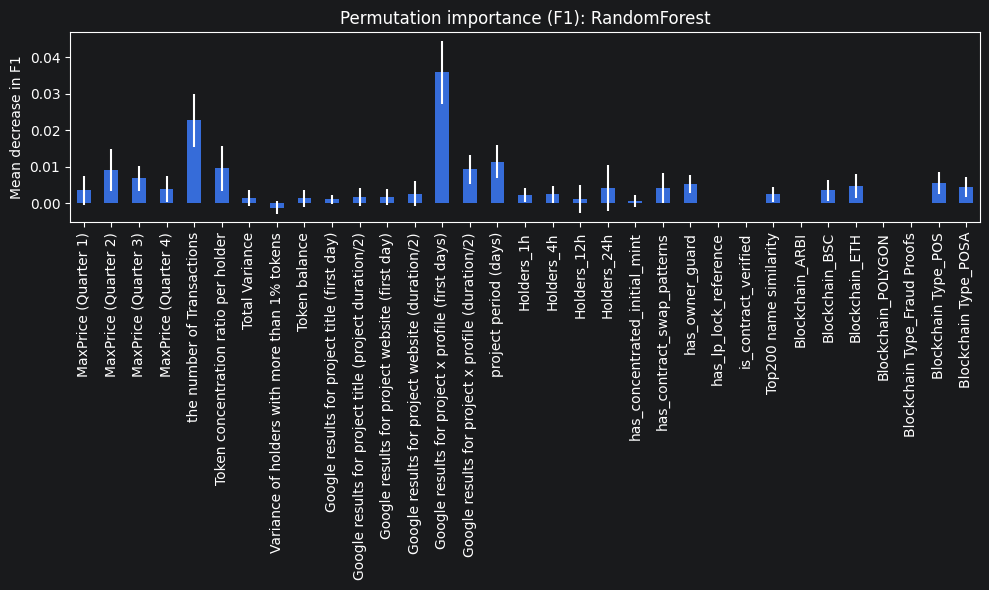

XGBoost
[('Google results for project x profile (first days)', np.float64(0.06895936239937621)), ('the number of Transactions', np.float64(0.03761070391989039)), ('Blockchain Type_POS', np.float64(0.010730823113717014)), ('Token concentration ratio per holder', np.float64(0.007686992135181603)), ('Google results for project title (project duration/2)', np.float64(0.006789902663578795)), ('project period (days)', np.float64(0.006496475938898061)), ('MaxPrice (Quarter 2)', np.float64(0.005515674494626988)), ('is_contract_verified', np.float64(0.004803540587219435)), ('Google results for project x profile (duration/2)', np.float64(0.004205845372796691)), ('Token balance', np.float64(0.004157205431669875)), ('Holders_12h', np.float64(0.0035141714855947857)), ('Google results for project website (first day)', np.float64(0.0029986791745084786)), ('Blockchain Type_POSA', np.float64(0.002643807997920322)), ('MaxPrice (Quarter 4)', np.float64(0.002573206902552194)), ('Blockchain_BSC', np.float6

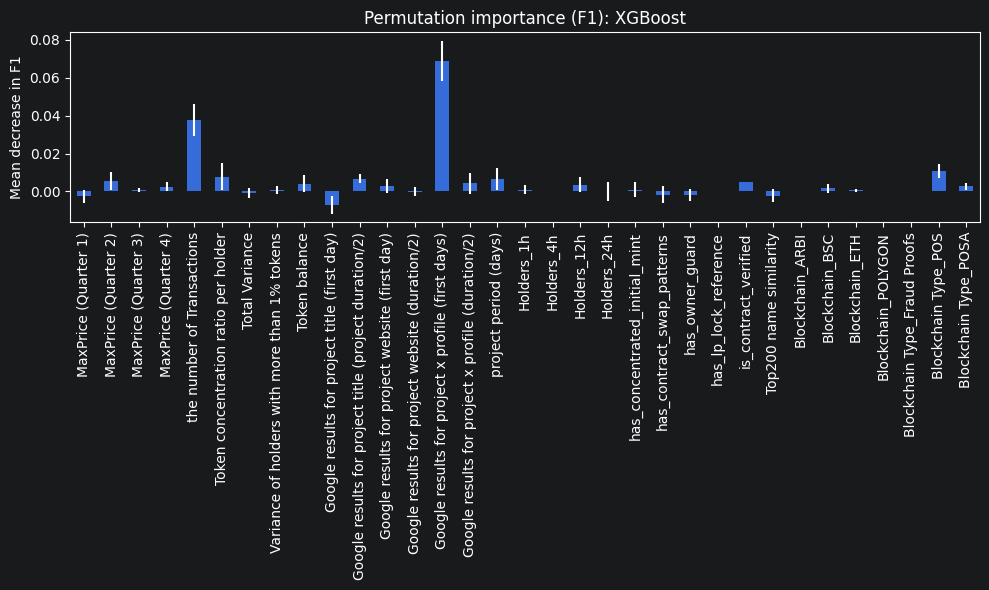

KNeighbors
[('Holders_1h', np.float64(0.035214889798514004)), ('Holders_12h', np.float64(0.021162606109023173)), ('Holders_4h', np.float64(0.020720178593784055)), ('project period (days)', np.float64(0.018145643543833866)), ('Token balance', np.float64(0.016738877089426098)), ('Variance of holders with more than 1% tokens', np.float64(0.014797675429032908)), ('Google results for project x profile (first days)', np.float64(0.014653674676518036)), ('Holders_24h', np.float64(0.012654322455224997)), ('Google results for project x profile (duration/2)', np.float64(0.012349879583088485)), ('Google results for project website (duration/2)', np.float64(0.012110687138198229)), ('MaxPrice (Quarter 1)', np.float64(0.011391408772071643)), ('MaxPrice (Quarter 4)', np.float64(0.01000188464259526)), ('Total Variance', np.float64(0.009087801988949994)), ('the number of Transactions', np.float64(0.006982858935540337)), ('MaxPrice (Quarter 3)', np.float64(0.006944333828232674)), ('Google results for pro

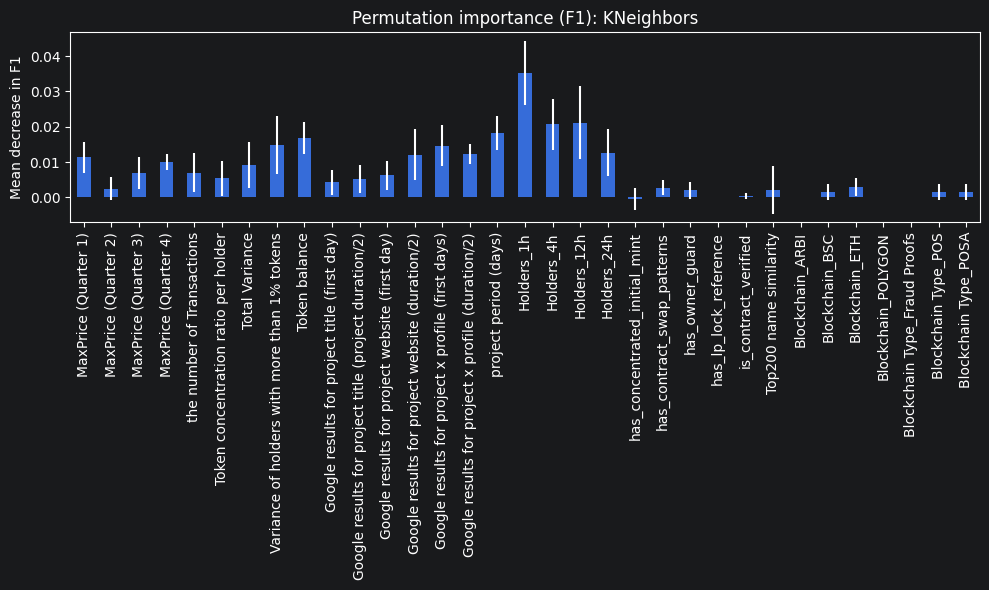

SVC
[('Google results for project x profile (first days)', np.float64(0.021009694522071787)), ('the number of Transactions', np.float64(0.017348119740963584)), ('Token concentration ratio per holder', np.float64(0.010473930278412613)), ('has_owner_guard', np.float64(0.005332523627675478)), ('has_contract_swap_patterns', np.float64(0.005110312262982997)), ('project period (days)', np.float64(0.0036569018485822944)), ('Blockchain Type_POS', np.float64(0.003147336543438739)), ('Blockchain Type_POSA', np.float64(0.003147336543438739)), ('Total Variance', np.float64(0.0028106058548089787)), ('Blockchain_ETH', np.float64(0.0021761162105455646)), ('Token balance', np.float64(0.00200400193132515)), ('Blockchain_BSC', np.float64(0.0019447983412401615)), ('is_contract_verified', np.float64(0.0019101670456445952)), ('MaxPrice (Quarter 4)', np.float64(0.0018156359543380796)), ('Holders_1h', np.float64(0.0017401840453682982)), ('Google results for project title (project duration/2)', np.float64(0.0

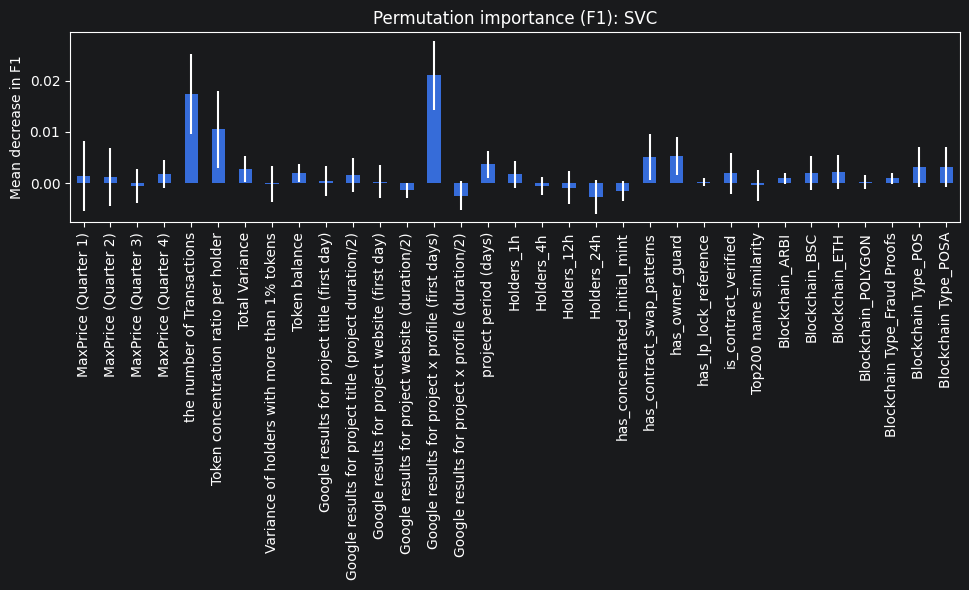

In [16]:
# Assess feature importance with permutation importance and plot the results

# Reference: A. Khan, A. Ali, J. Khan, F. Ullah and M. Faheem, "Using Permutation-Based Feature Importance for Improved Machine Learning Model Performance at Reduced Costs," in IEEE Access, vol. 13, pp. 36421-36435, 2025
# Reference: https://scikit-learn.org/stable/modules/permutation_importance.html

from sklearn.inspection import permutation_importance

def assess_feature_importance_with_permutation(name, model, X, Y, feature_names, n_repeats=10):
    result = permutation_importance(
        model, X, Y,
        scoring="f1",
        n_repeats=n_repeats,
        random_state=seed,
        n_jobs=-1
    )

    scores = dict(zip(feature_names, result.importances_mean))
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    print(name)
    print(sorted_scores)

    importances = pd.Series(result.importances_mean, index=feature_names)
    std = pd.Series(result.importances_std, index=feature_names)

    fig, ax = pyplot.subplots(figsize=(10, 6))
    importances.plot.bar(yerr=std, ax=ax)
    ax.set_title(f"Permutation importance (F1): {name}")
    ax.set_ylabel("Mean decrease in F1")
    fig.tight_layout()
    pyplot.show()

for name, model in models:
    assess_feature_importance_with_permutation(name, model, X_test, Y_test, feature_names)

RandomForest
[('the number of Transactions', np.float64(0.15235546011609685)), ('Token concentration ratio per holder', np.float64(0.12045397310691201)), ('Google results for project x profile (first days)', np.float64(0.09941100876874329)), ('Holders_24h', np.float64(0.05621209730694093)), ('project period (days)', np.float64(0.05598869784398706)), ('MaxPrice (Quarter 2)', np.float64(0.05240073112925175)), ('Google results for project x profile (duration/2)', np.float64(0.052001904581640376)), ('MaxPrice (Quarter 1)', np.float64(0.05004493148569907)), ('MaxPrice (Quarter 3)', np.float64(0.03725073815612246)), ('MaxPrice (Quarter 4)', np.float64(0.0364937543765679)), ('Holders_12h', np.float64(0.029966468467061285)), ('Total Variance', np.float64(0.02437086888770607)), ('Google results for project title (project duration/2)', np.float64(0.02233730935878658)), ('Variance of holders with more than 1% tokens', np.float64(0.02150255197493097)), ('Token balance', np.float64(0.02124448161627

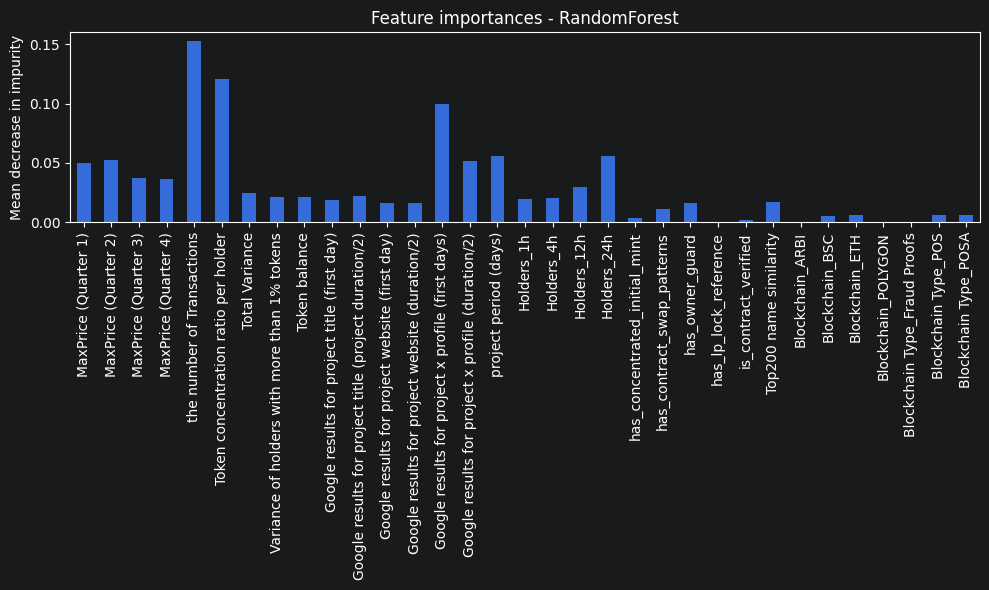

XGBoost
[('the number of Transactions', np.float32(0.18908381)), ('Blockchain_BSC', np.float32(0.10867544)), ('MaxPrice (Quarter 2)', np.float32(0.06301094)), ('has_contract_swap_patterns', np.float32(0.06291331)), ('is_contract_verified', np.float32(0.060647335)), ('Holders_12h', np.float32(0.05702628)), ('Google results for project x profile (first days)', np.float32(0.05614559)), ('Token concentration ratio per holder', np.float32(0.038111184)), ('has_owner_guard', np.float32(0.036531612)), ('Holders_24h', np.float32(0.027708095)), ('Token balance', np.float32(0.023155523)), ('Blockchain Type_POS', np.float32(0.023140488)), ('project period (days)', np.float32(0.02202145)), ('Google results for project title (project duration/2)', np.float32(0.021049647)), ('Google results for project x profile (duration/2)', np.float32(0.02071744)), ('Blockchain_ETH', np.float32(0.020069994)), ('MaxPrice (Quarter 1)', np.float32(0.018366335)), ('Variance of holders with more than 1% tokens', np.flo

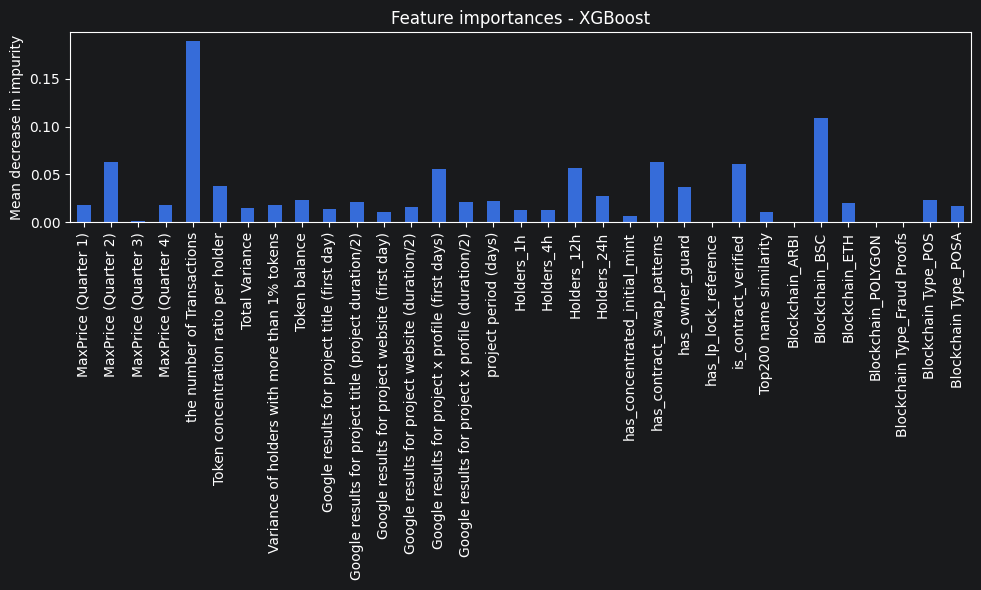

In [17]:
# Assess feature importance for Random Forest and XGBoost with feature_importances_ property and plot them

# Reference: CSM010-2024-APR, Topic 5. 5.12 Hands-on programming demo: evaluating models

def assess_feature_importance_RF_XGBoost_with_plots(name, model, feature_names):
    scores = dict(zip(feature_names, model.feature_importances_))
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    print(name)
    print(sorted_scores)

    importances = pd.Series(model.feature_importances_, index=feature_names)

    fig, ax = pyplot.subplots(figsize=(10, 6))
    importances.plot.bar(ax=ax)
    ax.set_title(f"Feature importances - {name}")
    ax.set_ylabel("Mean decrease in impurity")
    fig.tight_layout()
    pyplot.show()

for name, model in models:
    if name in ("RandomForest", "XGBoost"):
        assess_feature_importance_RF_XGBoost_with_plots(name, model, feature_names)

In [18]:
#TODO: describe the whole pipeline


#- load data -> create split -> drop columns -> encode class labels -> transfer data to numeric